## Ingest

In [1]:
import nltk
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder

In [2]:
train_data= pd.read_csv('data/twitter_training.csv', header = None)
valid_data = pd.read_csv('data/twitter_training.csv', header = None)

train_data.columns = ['ID', 'Category', 'Sentiment', 'Text']
valid_data.columns = ['ID', 'Category', 'Sentiment', 'Text']

In [89]:
train_data.head(100)
valid_data.head(100)

,ID,Category,Sentiment,Text,clean_text,label_encoded
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting borderlands murder,3
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,coming borders kill,3
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting borderlands kill,3
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming borderlands murder,3
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting borderlands murder,3
...,...,...,...,...,...,...
96,2417,Borderlands,Negative,Grounded almost looked pretty cool even despit...,grounded almost looked pretty cool even despit...,1
97,2417,Borderlands,Negative,Grounded looked cool despite the borderline un...,grounded looked cool despite borderline unfunn...,1
98,2417,Borderlands,Negative,"Grosskreutz looked pretty cool, even despite t...",grosskreutz looked pretty cool even despite un...,1
99,2417,Borderlands,Negative,Grounded almost looked pretty cool here despit...,grounded almost looked pretty cool despite bor...,1


## EDA

/mnt/c/Users/mzlwm/OneDrive/Documents/GitHub/twitter-sentiment-analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


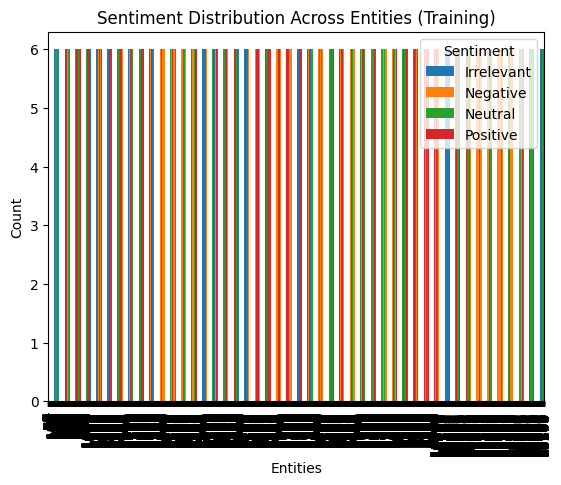

In [3]:
# Calculate sentiment distribution
sentiment_distribution_train = train_data.groupby('ID')['Sentiment'].value_counts().unstack(fill_value=0)
sentiment_distribution_valid = valid_data.groupby('ID')['Sentiment'].value_counts().unstack(fill_value=0)

# Plot sentiment distribution
sentiment_distribution_train.plot(kind='bar', stacked=True)
plt.title('Sentiment Distribution Across Entities (Training)')
plt.xlabel('Entities')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.show()

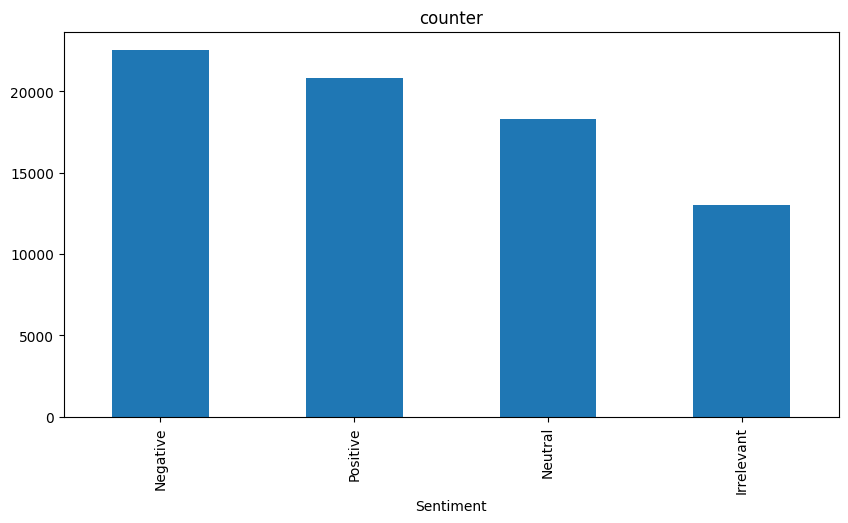

In [4]:
ax = train_data['Sentiment'].value_counts()\
     .plot(kind='bar',
           title = 'counter',
           figsize = (10,5))
ax.set_xlabel('Sentiment')
plt.show()


## Preprocessing

In [5]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mozaloom/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /home/mozaloom/nltk_data...
[nltk_data] Downloading package punkt to /home/mozaloom/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [6]:
def preprocess(text):
    text = str(text)
    text = re.sub(r'https?://\S+', '', text)# Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)# Remove special characters
    text = text.encode('ascii', 'ignore').decode('ascii')# Remove emojis
    text = text.lower()# Convert to lowercase

    tokens = word_tokenize(text)# Tokenize
    filtered_tokens = [word for word in tokens if word not in stop_words]  #remove stopwords
    return ' '.join(filtered_tokens)

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
train_data['clean_text'] = train_data['Text'].apply(preprocess)
valid_data['clean_text'] = valid_data['Text'].apply(preprocess)


[nltk_data] Downloading package punkt to /home/mozaloom/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mozaloom/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/mozaloom/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/mozaloom/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [13]:
label_encoder = LabelEncoder()
train_data['label_encoded'] = label_encoder.fit_transform(train_data['Sentiment'])
valid_data['label_encoded'] = label_encoder.transform(valid_data['Sentiment'])

In [14]:
train_data.head(100)

,ID,Category,Sentiment,Text,clean_text,label_encoded
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting borderlands murder,3
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,coming borders kill,3
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting borderlands kill,3
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming borderlands murder,3
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting borderlands murder,3
...,...,...,...,...,...,...
95,2416,Borderlands,Neutral,I hate that this easy horrible modifier event ...,hate easy horrible modifier event game last fo...,2
96,2417,Borderlands,Negative,Grounded almost looked pretty cool even despit...,grounded almost looked pretty cool even despit...,1
97,2417,Borderlands,Negative,Grounded looked cool despite the borderline un...,grounded looked cool despite borderline unfunn...,1
98,2417,Borderlands,Negative,"Grosskreutz looked pretty cool, even despite t...",grosskreutz looked pretty cool even despite un...,1


In [78]:
train_data.isnull().sum()
valid_data.isnull().sum()
train_data.dropna(inplace=True)
valid_data.dropna(inplace=True)

## Modeling

### TF-IDF & Passive Aggressive Classifier

In [30]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import os

# Function to train and save the model
def train_and_save_model(train_data, valid_data=None, save_model=True):
    """
    Train a TF-IDF + PassiveAggressiveClassifier model and save it
    
    Parameters:
    -----------
    train_data : pandas DataFrame
        Training data with 'clean_text' and 'Sentiment' columns
    valid_data : pandas DataFrame, optional
        Validation data with 'clean_text' and 'Sentiment' columns
    save_model : bool, default=True
        Whether to save the model to disk
        
    Returns:
    --------
    tfidf_vectorizer : TfidfVectorizer
        Fitted TF-IDF vectorizer
    pac : PassiveAggressiveClassifier
        Trained classifier
    accuracy : float, optional
        Validation accuracy if valid_data is provided
    """
    print("Training TF-IDF vectorizer...")
    tfidf_vectorizer = TfidfVectorizer()
    X_train_TF = tfidf_vectorizer.fit_transform(train_data['clean_text'])
    
    print(f"Training PassiveAggressiveClassifier on {X_train_TF.shape[0]} samples...")
    pac = PassiveAggressiveClassifier(max_iter=50)
    pac.fit(X_train_TF, train_data['Sentiment'])
    
    # Evaluate on validation data if provided
    if valid_data is not None:
        print("Evaluating on validation data...")
        X_valid_TF = tfidf_vectorizer.transform(valid_data['clean_text'])
        y_pred = pac.predict(X_valid_TF)
        accuracy = accuracy_score(valid_data['Sentiment'], y_pred)
        print(f'Validation Accuracy: {round(accuracy*100, 2)}%')
        
        # Print detailed metrics
        print("\nClassification Report:")
        print(classification_report(valid_data['Sentiment'], y_pred))
        
        # Print confusion matrix
        cm = confusion_matrix(valid_data['Sentiment'], y_pred)
        print("\nConfusion Matrix:")
        print(cm)
    
    # Save the model and vectorizer if requested
    if save_model:
        print("Saving model and vectorizer...")
        if not os.path.exists('models'):
            os.makedirs('models')
        joblib.dump(tfidf_vectorizer, 'models/tfidf_vectorizer.pkl')
        joblib.dump(pac, 'models/pac_classifier.pkl')
        print("Model saved to 'models/' directory")
    
    if valid_data is not None:
        return tfidf_vectorizer, pac, accuracy
    else:
        return tfidf_vectorizer, pac

In [31]:
# Function to load model
def load_model(vectorizer_path='models/tfidf_vectorizer.pkl', 
               model_path='models/pac_classifier.pkl'):
    """
    Load the saved TF-IDF vectorizer and PassiveAggr/essiveClassifier
    
    Parameters:
    -----------
    vectorizer_path : str
        Path to the saved TF-IDF vectorizer
    model_path : str
        Path to the saved PassiveAggressiveClassifier
        
    Returns:
    --------
    tfidf_vectorizer : TfidfVectorizer
        Loaded TF-IDF vectorizer
    pac : PassiveAggressiveClassifier
        Loaded classifier
    """
    try:
        tfidf_vectorizer = joblib.load(vectorizer_path)
        pac = joblib.load(model_path)
        print("Model loaded successfully")
        return tfidf_vectorizer, pac
    except Exception as e:
        print(f"Error loading model: {e}")
        return None, None


In [32]:
# Function to make predictions on new data
def predict_sentiment(texts, tfidf_vectorizer=None, pac=None, 
                      vectorizer_path='models/tfidf_vectorizer.pkl',
                      model_path='models/pac_classifier.pkl'):
    """
    Predict sentiment for new texts
    
    Parameters:
    -----------
    texts : list or pandas Series
        List of texts to predict sentiment for
    tfidf_vectorizer : TfidfVectorizer, optional
        Pre-loaded TF-IDF vectorizer (will load from disk if not provided)
    pac : PassiveAggressiveClassifier, optional
        Pre-loaded classifier (will load from disk if not provided)
    vectorizer_path : str
        Path to the saved TF-IDF vectorizer if loading from disk
    model_path : str
        Path to the saved classifier if loading from disk
        
    Returns:
    --------
    predictions : numpy array
        Predicted sentiment labels
    """
    # Load model if not provided
    if tfidf_vectorizer is None or pac is None:
        tfidf_vectorizer, pac = load_model(vectorizer_path, model_path)
        if tfidf_vectorizer is None or pac is None:
            print("Failed to load model. Cannot make predictions.")
            return None
    
    # Preprocess texts if they're in a DataFrame or Series
    if isinstance(texts, pd.DataFrame) and 'clean_text' in texts.columns:
        texts = texts['clean_text']
    
    # Convert to list if it's a pandas Series
    if isinstance(texts, pd.Series):
        texts = texts.tolist()
    
    # Ensure texts is a list
    if not isinstance(texts, list):
        texts = [texts]
    
    # Transform texts using TF-IDF
    X_tfidf = tfidf_vectorizer.transform(texts)
    
    # Make predictions
    predictions = pac.predict(X_tfidf)
    
    return predictions

In [33]:
# Function to test on a few examples
def test_model_inference():
    """Test the model on a few example texts"""
    # Try to load the model
    tfidf_vectorizer, pac = load_model()
    
    # If model doesn't exist yet, train on the existing data
    if tfidf_vectorizer is None or pac is None:
        print("No saved model found. Please train the model first using:")
        print("tfidf_vectorizer, pac = train_and_save_model(train_data, valid_data)")
        return
    
    # Example texts
    example_texts = [
        "I love this product! It's amazing and works perfectly.",
        "This is terrible. Completely disappointed with the purchase.",
        "It's okay, not great but not bad either.",
        "The customer service was helpful but the product broke after a week."
    ]
    
    # Make predictions
    predictions = predict_sentiment(example_texts, tfidf_vectorizer, pac)
    
    # Display results
    print("\nTest Results:")
    for text, prediction in zip(example_texts, predictions):
        print(f"Text: {text[:50]}{'...' if len(text) > 50 else ''}")
        print(f"Predicted sentiment: {prediction}")
        print("-" * 50)

In [34]:
# Make sure train_data and valid_data are defined with 'clean_text' and 'Sentiment' columns
tfidf_vectorizer, pac, accuracy = train_and_save_model(train_data, valid_data)

Training TF-IDF vectorizer...
Training PassiveAggressiveClassifier on 74682 samples...
Evaluating on validation data...
Validation Accuracy: 93.99%

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.95      0.93      0.94     12990
    Negative       0.96      0.94      0.95     22542
     Neutral       0.95      0.93      0.94     18318
    Positive       0.90      0.95      0.93     20832

    accuracy                           0.94     74682
   macro avg       0.94      0.94      0.94     74682
weighted avg       0.94      0.94      0.94     74682


Confusion Matrix:
[[12031   243   189   527]
 [  195 21205   286   856]
 [  179   268 17096   775]
 [  257   377   338 19860]]
Saving model and vectorizer...
Model saved to 'models/' directory


In [35]:
# Load the saved model
tfidf_vectorizer, pac = load_model()

# Make predictions on new data
new_texts = ["This movie was absolutely excellent!", "The service was terrible and disappointing"]
predictions = predict_sentiment(new_texts, tfidf_vectorizer, pac)
print(predictions)

Model loaded successfully
['Positive' 'Negative']


In [ ]:
# If you have a DataFrame with a 'clean_text' column
test_predictions = predict_sentiment("i love b", tfidf_vectorizer, pac)
print(test_predictions)

['Positive']


In [46]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Function to evaluate model accuracy
def check_model_accuracy(tfidf_vectorizer, pac_model, valid_data):
    """
    Check the accuracy of the TF-IDF + PAC model on validation data
    
    Parameters:
    -----------
    tfidf_vectorizer : fitted TfidfVectorizer
    pac_model : fitted PassiveAggressiveClassifier
    valid_data : pandas DataFrame with 'clean_text' and 'Sentiment' columns
    
    Returns:
    --------
    accuracy : float
        Accuracy score (0-1)
    """
    # Transform validation data
    X_valid_TF = tfidf_vectorizer.transform(valid_data['clean_text'])
    
    # Make predictions
    y_pred = pac_model.predict(X_valid_TF)
    
    # Calculate accuracy
    accuracy = accuracy_score(valid_data['Sentiment'], y_pred)
    
    # Print results
    print(f'Validation Accuracy: {round(accuracy*100, 2)}%')
    
    # Print detailed classification report
    print("\nClassification Report:")
    print(classification_report(valid_data['Sentiment'], y_pred))
    
    # Print confusion matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(valid_data['Sentiment'], y_pred)
    print(cm)
    
    return accuracy, y_pred

# Function to evaluate and compare with original implementation
def verify_implementation():
    """
    Re-run the original implementation and check accuracy
    """
    print("Re-running original implementation...")
    
    # Re-train the model exactly as in the original code
    tfidf_vectorizer = TfidfVectorizer()
    X_train_TF = tfidf_vectorizer.fit_transform(train_data['clean_text'])
    X_valid_TF = tfidf_vectorizer.transform(valid_data['clean_text'])
    
    pac = PassiveAggressiveClassifier(max_iter=50)
    pac.fit(X_train_TF, train_data['Sentiment'])
    
    # Check accuracy on validation data
    y_pred = pac.predict(X_valid_TF)
    accuracy = accuracy_score(valid_data['Sentiment'], y_pred)
    print(f'Validation Accuracy: {round(accuracy*100, 2)}%')
    
    return tfidf_vectorizer, pac, accuracy

# Function to analyze incorrect predictions
def analyze_errors(valid_data, y_pred):
    """
    Analyze incorrect predictions to understand model weaknesses
    
    Parameters:
    -----------
    valid_data : pandas DataFrame with 'clean_text' and 'Sentiment' columns
    y_pred : array-like
        Predicted sentiment labels
    
    Returns:
    --------
    error_examples : pandas DataFrame
        DataFrame with examples of incorrect predictions
    """
    # Create a copy of validation data
    error_analysis = valid_data.copy()
    
    # Add predicted sentiment column
    error_analysis['predicted_sentiment'] = y_pred
    
    # Add column to indicate correct/incorrect predictions
    error_analysis['correct'] = error_analysis['Sentiment'] == error_analysis['predicted_sentiment']
    
    # Extract incorrect predictions
    incorrect_predictions = error_analysis[~error_analysis['correct']]
    
    # Print error statistics
    print(f"Total validation samples: {len(valid_data)}")
    print(f"Correct predictions: {sum(error_analysis['correct'])}")
    print(f"Incorrect predictions: {len(incorrect_predictions)}")
    
    # Sample a few incorrect predictions to examine
    if len(incorrect_predictions) > 0:
        print("\nSample of incorrect predictions:")
        sample_size = min(5, len(incorrect_predictions))
        samples = incorrect_predictions.sample(sample_size)
        
        for i, row in samples.iterrows():
            print("-" * 60)
            print(f"Text: {row['clean_text'][:100]}...")
            print(f"True sentiment: {row['Sentiment']}")
            print(f"Predicted sentiment: {row['predicted_sentiment']}")
    
    return incorrect_predictions

# Usage example:
"""
# If you already have a trained model and vectorizer, check accuracy:
accuracy, y_pred = check_model_accuracy(tfidf_vectorizer, pac, valid_data)

# To re-run and verify original implementation:
tfidf_vectorizer, pac, accuracy = verify_implementation()

# To analyze prediction errors:
error_examples = analyze_errors(valid_data, y_pred)
"""

# IMPORTANT: If your original trained model is already in variables 'tfidf_vectorizer' and 'pac',
# simply run this one line to check accuracy:
#  check_model_accuracy(tfidf_vectorizer, pac, valid_data)

'\n# If you already have a trained model and vectorizer, check accuracy:\naccuracy, y_pred = check_model_accuracy(tfidf_vectorizer, pac, valid_data)\n\n# To re-run and verify original implementation:\ntfidf_vectorizer, pac, accuracy = verify_implementation()\n\n# To analyze prediction errors:\nerror_examples = analyze_errors(valid_data, y_pred)\n'

In [47]:
 check_model_accuracy(tfidf_vectorizer, pac, valid_data)

Validation Accuracy: 93.99%

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.95      0.93      0.94     12990
    Negative       0.96      0.94      0.95     22542
     Neutral       0.95      0.93      0.94     18318
    Positive       0.90      0.95      0.93     20832

    accuracy                           0.94     74682
   macro avg       0.94      0.94      0.94     74682
weighted avg       0.94      0.94      0.94     74682


Confusion Matrix:
[[12031   243   189   527]
 [  195 21205   286   856]
 [  179   268 17096   775]
 [  257   377   338 19860]]


(0.939878417824911,
 array(['Positive', 'Positive', 'Negative', ..., 'Positive', 'Positive',
        'Positive'], shape=(74682,), dtype='<U10'))

### Roberta

In [ ]:
#Roberta model
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import pandas as pd
import torch
from scipy.special import softmax
from tqdm.notebook import tqdm  # Using notebook-specific tqdm

In [21]:
# Try to use tqdm.notebook, but fall back to regular tqdm if it fails
try:
    from tqdm.notebook import tqdm
except ImportError:
    try:
        from tqdm import tqdm
    except ImportError:
        # Define a simple fallback if tqdm is not available
        def tqdm(iterable, total=None, **kwargs):
            if total:
                print(f"Processing {total} items...")
            return iterable

In [ ]:


MODEL = f'cardiffnlp/twitter-roberta-base-sentiment'
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

In [24]:

def polarity_scores_roberta(text):
    """Get sentiment scores for a text using RoBERTa"""
    # Ensure text is a string
    if not isinstance(text, str):
        text = str(text)
        
    # Handle empty text
    if not text.strip():
        return {
            'roberta_neg': 0.0,
            'roberta_neu': 1.0,
            'roberta_pos': 0.0
        }
    
    # Process text through model
    encoded_text = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
    with torch.no_grad():  # Disable gradient calculation for inference
        output = model(**encoded_text)
    
    # Get probabilities using softmax
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    
    # RoBERTa from cardiffnlp has outputs as [negative, neutral, positive]
    return {
        'roberta_neg': float(scores[0]),
        'roberta_neu': float(scores[1]),
        'roberta_pos': float(scores[2])
    }


In [25]:

# Alternative method without tqdm if you continue having issues
def process_without_tqdm(df, limit=1000):
    res = {}
    counter = 0
    total_rows = min(len(df), limit)
    
    print(f"Starting to process {total_rows} texts...")
    
    # Print progress every 100 items
    for i, row in df.iterrows():
        if counter >= limit:
            break
            
        text = row['Text']
        myid = row['ID']
        res[myid] = polarity_scores_roberta(text)
        
        counter += 1
        if counter % 100 == 0:
            print(f"Processed {counter}/{total_rows} texts")
    
    print(f"Completed processing {counter} texts.")
    return res

In [26]:
# Method 1: Using tqdm with error handling
def process_with_tqdm():
    res = {}
    counter = 0
    try:
        for i, row in tqdm(train_data.iterrows(), total=1000):
            text = row['Text']
            myid = row['ID']
            res[myid] = polarity_scores_roberta(text)
            counter += 1
            if counter == 1000:
                break
    except Exception as e:
        print(f"Error with tqdm: {e}")
        # Fall back to non-tqdm method
        return process_without_tqdm(train_data)
    
    return res

In [27]:
# Process the dataset - choose the method that works for you
# Option 1: Use the tqdm version with fallback
res = process_with_tqdm()

# Option 2: Or directly use the simpler version without tqdm
# res = process_without_tqdm(train_data)

# Convert results to DataFrame and merge with original data
robertas = pd.DataFrame(res).T
robertas = robertas.reset_index().rename(columns={'index': 'ID'})
robertas = robertas.merge(train_data, how='left')

# Display the results
robertas.head()

Error with tqdm: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
Starting to process 1000 texts...
Processed 100/1000 texts
Processed 200/1000 texts
Processed 300/1000 texts
Processed 400/1000 texts
Processed 500/1000 texts
Processed 600/1000 texts
Processed 700/1000 texts
Processed 800/1000 texts
Processed 900/1000 texts


Exception ignored in: <function tqdm.__del__ at 0x7f86c82f5b20>
Traceback (most recent call last):
  File "/mnt/c/Users/mzlwm/OneDrive/Documents/GitHub/twitter-sentiment-analysis/.venv/lib/python3.12/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/mnt/c/Users/mzlwm/OneDrive/Documents/GitHub/twitter-sentiment-analysis/.venv/lib/python3.12/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


Processed 1000/1000 texts
Completed processing 1000 texts.


,ID,roberta_neg,roberta_neu,roberta_pos,Category,Sentiment,Text,clean_text,label_encoded
0,2401,0.778829,0.196587,0.024584,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting borderlands murder,3
1,2401,0.778829,0.196587,0.024584,Borderlands,Positive,I am coming to the borders and I will kill you...,coming borders kill,3
2,2401,0.778829,0.196587,0.024584,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting borderlands kill,3
3,2401,0.778829,0.196587,0.024584,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming borderlands murder,3
4,2401,0.778829,0.196587,0.024584,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting borderlands murder,3


In [ ]:

# Example for a single text inference
def test_single_inference(test_text):
    test_text = "I really enjoyed this movie. The acting was great!"
    result = polarity_scores_roberta(test_text)
    print(f"Text: {test_text}")
    print(f"Sentiment scores: {result}")

In [29]:
    
# Uncomment to run the test
test_single_inference()

Text: I really enjoyed this movie. The acting was great!
Sentiment scores: {'roberta_neg': 0.0015983455814421177, 'roberta_neu': 0.0053862230852246284, 'roberta_pos': 0.9930154085159302}


### Bag-of-Words & Passive Aggressive Classifier

In [81]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

In [82]:
# Create Bag-of-Words vectorizer
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(train_data['clean_text'])
X_valid_bow = bow_vectorizer.transform(valid_data['clean_text'])  # Note: Using X_valid_bow instead of X_valid_TF

# Train Passive Aggressive Classifier
pac = PassiveAggressiveClassifier(max_iter=50)
pac.fit(X_train_bow, train_data['Sentiment'])

# Predict on validation set
y_pred_bow = pac.predict(X_valid_bow)  # This was incorrect in your code (used X_valid_TF instead of X_valid_bow)
score = accuracy_score(valid_data['Sentiment'], y_pred_bow)
print(f'Accuracy: {round(score*100, 2)}%')

# Additional detailed accuracy metrics
from sklearn.metrics import classification_report, confusion_matrix
print("\nDetailed Classification Report:")
print(classification_report(valid_data['Sentiment'], y_pred_bow))

print("\nConfusion Matrix:")
print(confusion_matrix(valid_data['Sentiment'], y_pred_bow))


Accuracy: 93.3%

Detailed Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.96      0.92      0.94     12875
    Negative       0.95      0.93      0.94     22358
     Neutral       0.95      0.93      0.94     18108
    Positive       0.88      0.95      0.92     20655

    accuracy                           0.93     73996
   macro avg       0.94      0.93      0.93     73996
weighted avg       0.93      0.93      0.93     73996


Confusion Matrix:
[[11813   242   203   617]
 [  168 20791   300  1099]
 [  113   312 16777   906]
 [  207   471   319 19658]]


In [83]:
# Inference function for new text
def predict_sentiment(text, vectorizer, model):
    """
    Predict sentiment for new text using the trained model
    
    Args:
        text (str or list): Input text or list of texts
        vectorizer: Fitted CountVectorizer 
        model: Trained classifier
    
    Returns:
        prediction: Predicted sentiment class(es)
    """
    # Handle single text input
    if isinstance(text, str):
        text = [text]
    
    # Transform text using the same vectorizer
    text_bow = vectorizer.transform(text)
    
    # Predict sentiment
    prediction = model.predict(text_bow)
    
    return prediction


In [84]:
# Example usage:
example_texts = [
    "I really enjoyed this movie, it was fantastic!",
    "I love the new design of the product.",
    "The service was okay, nothing special."
]

predictions = predict_sentiment(example_texts, bow_vectorizer, pac)

# Print results
for text, sentiment in zip(example_texts, predictions):
    print(f"Text: '{text}'")
    print(f"Predicted sentiment: {sentiment}")
    print("-" * 50)

Text: 'I really enjoyed this movie, it was fantastic!'
Predicted sentiment: Positive
--------------------------------------------------
Text: 'I love the new design of the product.'
Predicted sentiment: Positive
--------------------------------------------------
Text: 'The service was okay, nothing special.'
Predicted sentiment: Irrelevant
--------------------------------------------------


In [85]:
# Save the model and vectorizer for future use
import pickle

# Save model
with open('pac_sentiment_model.pkl', 'wb') as f:
    pickle.dump(pac, f)

# Save vectorizer
with open('bow_vectorizer.pkl', 'wb') as f:
    pickle.dump(bow_vectorizer, f)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [86]:
# Example of loading and using the saved model
def load_model_and_predict(text):
    # Load model and vectorizer
    with open('models/pac_sentiment_model.pkl', 'rb') as f:
        loaded_model = pickle.load(f)
    
    with open('models/bow_vectorizer.pkl', 'rb') as f:
        loaded_vectorizer = pickle.load(f)
    
    # Make prediction
    return predict_sentiment(text, loaded_vectorizer, loaded_model)

In [87]:
print(load_model_and_predict("I didn't like the movie at all. It was boring."))

['Negative']
